# Secure Aggregation Performance Test Demo

This is a demo testing communication cost, redundant calculation cost of specific MPC protocol.

## 1. The ASS-based MPC protocol

The protocol to be tested is based on Addtictive Secret Sharing:
$a = \sum \limits_{i=1}^{n} a^i, b = \sum \limits_{i=1}^{n} b^i$, where $a^i, b^i$ is the partion
of secret $a$ and $b$, stored and kept secret by each calculate part.

Numerical add: $x = a + y$, let $x^0 = a+y^0$

Numerical mul: $x = a \times y$, let $x^i = a \times y^i$ for all i-th part.

Secretly add: $z = x+y$, let $z^i = x^i + y^i$ for each $i$.

Secretly mul: $z = x \times y$, use `Beaver Triples`:
    1. generate secrets $a, b, c, c = a \times b$, each part has $c^i, a^i, b^i$
    2. each part calculates $\epsilon^i = x^i - a^i, \rho ^i = y^i - b^i$
    3. decipher and open $\epsilon, \rho$ to public.
    4. each part calculates $z^i = c^i + \epsilon b^i + \rho a^i + \epsilon \rho$

So, it's necessary for secret multiplication to generate Beaver Triples previously. We use COPE, which is used in MASCOT protocol, to solve this.

## 2. The Secure Aggregation Policy

we use `FedAvg` Policy. 

$\textbf{w} = \sum \limits_{i=1}^{n} \frac{n_i}{n} \textbf{w}_i$, where $n = \sum \limits_{i} n_i$

将每个终端的参数$h_i$加一个随机参数$r_i$：$g_i = h_i+r_i$，然后分发$g_i^k$（$g_i^k$表示的第i个终端自己的张量$g_i$分给k号终端的加性秘密共享分量，$x_i^k, h_i^k, \textbf{h}^k$同理）、$r_i^k$，最后每个k号终端计算$l^k = \sum \limits_{i} g_i^k - r_i^k$，然后把$l^k$发给聚合中心，聚合中心计算$\sum \limits_{k} l^k = \sum \limits_{i} h_i$。如果采用 `FedAvg`的$h = \sum \limits_{i} \frac{n_i}{n} h_i, n = \sum \limits_i n_i$，那么把$n_i h_i$当作$h_i$进行聚合就行，并且把$n_i$发给聚合中心，聚合中心聚合后除以$n$完事。

## 3. Code Implementation


In [35]:
%matplotlib inline
import collections

import tensorflow_federated as tff
import tensorflow as tf
import numpy as np

np.random.seed(20050505)

@tff.tensorflow.computation(tff.TensorType(shape=[None, None], dtype=np.float32))
def calc_a(a):
    return tf.reduce_mean(a, axis=1)

print(calc_a(np.array([[1,2], [2, 3], [3, 4]], dtype=np.float32)))

[1.5 2.5 3.5]


Load MNIST data.

In [36]:
emnist_train, emnist_test = tff.simulation.datasets.emnist.load_data()

In [37]:
print(len(emnist_train.client_ids), len(emnist_test.client_ids))
print(emnist_train.element_type_structure)

element_dataset = emnist_train.create_tf_dataset_for_client(emnist_train.client_ids[0])
element_iter = iter(element_dataset)
element = next(element_iter)
for i in range(10):
    element = next(element_iter)
    print(element['label'].numpy())

3383 3383
OrderedDict([('label', TensorSpec(shape=(), dtype=tf.int32, name=None)), ('pixels', TensorSpec(shape=(28, 28), dtype=tf.float32, name=None))])
0
0
1
1
0
0
1
1
1
1


In [38]:
print(element_dataset)

<_ParallelMapDataset element_spec=OrderedDict([('label', TensorSpec(shape=(), dtype=tf.int32, name=None)), ('pixels', TensorSpec(shape=(28, 28), dtype=tf.float32, name=None))])>


(3, 10)


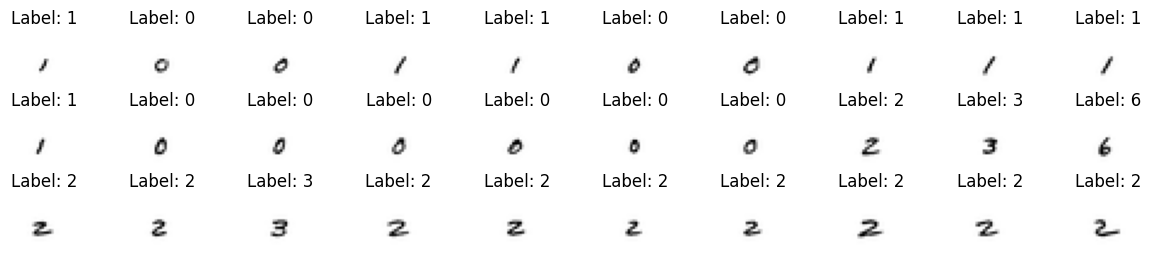

In [39]:
from matplotlib import pyplot as plt

import math

def show_samples(dataset, num_samples=5):
    fig, axes = plt.subplots(math.ceil(num_samples / 10), 10, figsize=(15, 3))
    print(axes.shape)
    for i, element in enumerate(dataset.take(num_samples)):
        n = i // 10
        m = i % 10
        pixels = element['pixels'].numpy()
        # pixels = element['pixels'].numpy().reshape(28, 28)
        axes[n][m].imshow(pixels, cmap='gray')
        axes[n][m].set_title(f"Label: {element['label'].numpy()}")
        axes[n][m].axis('off')
    plt.show()

show_samples(element_dataset, 30)

### 3.1 The appearance of train data's heterogeneity

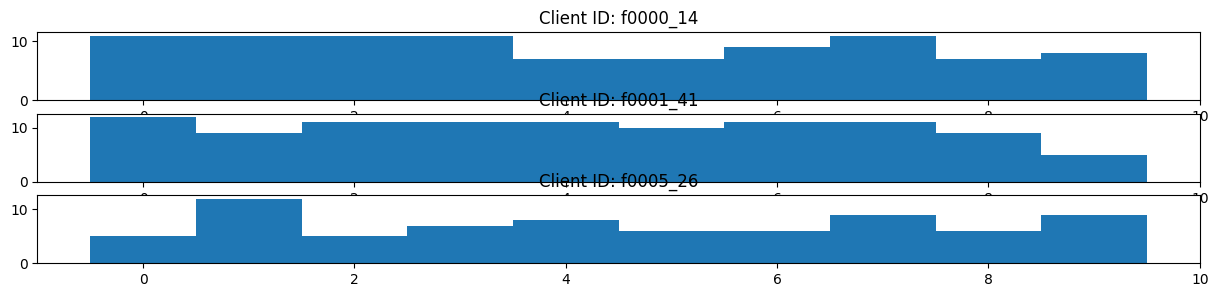

In [40]:
def show_client_data_dist(datasets, num_clients = 3) :
    fig, axes = plt.subplots(num_clients, 1, figsize = (15,3))
    for i, client_id in enumerate(datasets.client_ids[:num_clients]) :
        dataset = datasets.create_tf_dataset_for_client(client_id)
        labels = [example['label'].numpy() for example in dataset.take(100)]
        axes[i].set_title(f"Client ID: {client_id}")
        axes[i].hist(labels, bins=np.arange(11), align='left')

show_client_data_dist(emnist_train, 3)

### 3.2 Preprocess Data

use shuffled epochs.

Because the ERM target of 1 epoch and several epochs is equivalent.

In [41]:
import yaml

with open("./config.yaml", mode="r") as f:
    config = yaml.safe_load(f)

def preprocess(dataset) :

    def batch_flatten(element) :
        normal_pixels = tf.cast(element['pixels'], tf.float32) / 255.0
        return collections.OrderedDict(x=normal_pixels,
                                       y=tf.reshape(element['label'], [1,]))

    return ( dataset.repeat(config['num_epoch'])
        .shuffle(config['preprocess']['shuffle_buffer_size'])
        .map(batch_flatten)
        .batch(config['batch_size'])
        .prefetch(config['preprocess']['prefetch_buffer_size']))

def make_federated_data(client_data, client_ids) :
    return [preprocess(client_data.create_tf_dataset_for_client(x)) for x in client_ids]

In [42]:
sample_clients = emnist_train.client_ids[0:config['num_clients']]

federated_train_data = make_federated_data(emnist_train, sample_clients)
print("Number of clients in federated data: {}".format(len(federated_train_data)))
print("The first client's data: {}".format(federated_train_data[0]))

Number of clients in federated data: 10
The first client's data: <_PrefetchDataset element_spec=OrderedDict([('x', TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name=None)), ('y', TensorSpec(shape=(None, 1), dtype=tf.int32, name=None))])>


### 3.3 Construct tff model and run it

We use `tff.kerase` to construct a fully-connected NN quickly.

In [43]:
def create_keras_model() :
    return tf.keras.models.Sequential([
        tf.keras.layers.InputLayer(input_shape=(28, 28)),
        tf.keras.layers.Reshape(target_shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(32, kernel_size=3, activation='relu'),
        tf.keras.layers.MaxPool2D(pool_size=2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax")]
    )


def create_tff_model() :
    keras_model = create_keras_model()
    return tff.learning.models.from_keras_model( keras_model,
        input_spec=federated_train_data[0].element_spec,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[tf.keras.metrics.CategoricalAccuracy()])

In [44]:
print(federated_train_data[0].element_spec)

OrderedDict([('x', TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name=None)), ('y', TensorSpec(shape=(None, 1), dtype=tf.int32, name=None))])


In [45]:
training_process = tff.learning.algorithms.build_weighted_fed_avg(
    model_fn=create_tff_model,
    client_optimizer_fn=tff.learning.optimizers.build_sgdm(
        learning_rate=config['client_learning_rate'],
        momentum=config['client_momentum']),
    server_optimizer_fn=tff.learning.optimizers.build_sgdm(
        learning_rate=config['server_learning_rate'])
)

print(training_process.initialize.type_signature.formatted_representation())

( -> <
  global_model_weights=<
    trainable=<
      float32[3,3,1,32],
      float32[32],
      float32[5408,128],
      float32[128],
      float32[128,10],
      float32[10]
    >,
    non_trainable=<>
  >,
  distributor=<>,
  client_work=<
    learning_rate=float32,
    momentum=float32
  >,
  aggregator=<
    value_sum_process=<>,
    weight_sum_process=<>
  >,
  finalizer=<
    learning_rate=float32
  >
>@SERVER)


Initialize it.

In [46]:
train_state = training_process.initialize()

2026-05-06 00:51:57.916339: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
2026-05-06 00:51:57.916460: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-05-06 00:51:57.927802: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
2026-05-06 00:51:57.927901: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session


run once, see the format of results.

In [47]:
result = training_process.next(train_state, federated_train_data)
train_state = result.state
train_metrics = result.metrics
print(f"round 1, train metrics: {train_metrics}")

2026-05-06 00:51:58.091180: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
2026-05-06 00:51:58.091306: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-05-06 00:51:58.165251: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
2026-05-06 00:51:58.165385: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-05-06 00:51:58.171598: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
2026-05-06 00:51:58.171702: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-05-06 00:51:58.176896: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
2026-05-06 00:51:58.176990: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session


round 1, train metrics: OrderedDict([('distributor', ()), ('client_work', OrderedDict([('train', OrderedDict([('categorical_accuracy', 0.12860082), ('loss', 2.2963302), ('num_examples', 29160), ('num_batches', 917)]))])), ('aggregator', OrderedDict([('mean_value', ()), ('mean_weight', ())])), ('finalizer', OrderedDict([('update_non_finite', 0)]))])


run several rounds.

In [48]:
for epoch in range(config['num_epoch']):
    result = training_process.next(train_state, federated_train_data)
    train_state = result.state
    train_metrics = result.metrics
    print(f"round {epoch+1}, loss: {train_metrics['client_work']['train']['loss']}, \
        accuracy: {train_metrics['client_work']['train']['categorical_accuracy']}")

round 1, loss: 2.2939276695251465,         accuracy: 0.1141289472579956
round 2, loss: 2.293670415878296,         accuracy: 0.14705075323581696
round 3, loss: 2.2944772243499756,         accuracy: 0.11522633582353592
round 4, loss: 2.2928714752197266,         accuracy: 0.12620027363300323
round 5, loss: 2.2946767807006836,         accuracy: 0.14519889652729034
round 6, loss: 2.294696092605591,         accuracy: 0.09218107163906097
round 7, loss: 2.2940514087677,         accuracy: 0.1160493791103363
round 8, loss: 2.293877601623535,         accuracy: 0.08189300447702408
round 9, loss: 2.2939293384552,         accuracy: 0.12839506566524506
round 10, loss: 2.2945501804351807,         accuracy: 0.09176954627037048
round 11, loss: 2.293752431869507,         accuracy: 0.10226337611675262
round 12, loss: 2.294121026992798,         accuracy: 0.1141289472579956
round 13, loss: 2.2936360836029053,         accuracy: 0.0855967104434967
round 14, loss: 2.293722152709961,         accuracy: 0.0959533

In [49]:
a = training_process.get_model_weights(train_state).trainable   
print(len(a))
for x in a:
    print(x.shape)

6
(3, 3, 1, 32)
(32,)
(5408, 128)
(128,)
(128, 10)
(10,)


(693962,)
0.20702377 -0.20719676


(array([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.00

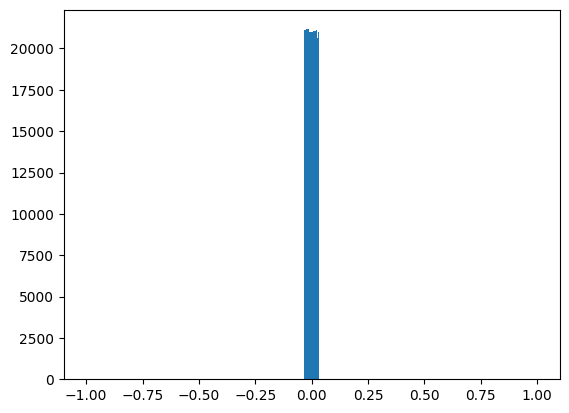

In [50]:
a = training_process.get_model_weights(train_state).trainable
b = np.concatenate([x.flatten() for x in a])
print(b.shape)
print(b.max(), b.min())
plt.hist(b.flatten(), bins=1000, range=(-1, 1))

### 3.4 Evaluate

use `tff.learning.algorithms.build_fed_eval` to evaluate model.

In [51]:
evaluate_process = tff.learning.algorithms.build_fed_eval(
    model_fn=create_tff_model,
)


In [52]:
evaluate_state = evaluate_process.initialize()
model_weights = training_process.get_model_weights(train_state)
evaluate_state = evaluate_process.set_model_weights(evaluate_state, model_weights)

2026-05-06 00:54:20.186575: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
2026-05-06 00:54:20.186698: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-05-06 00:54:20.200898: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
2026-05-06 00:54:20.201115: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session


In [53]:
evaluate_result = evaluate_process.next(evaluate_state, make_federated_data(emnist_test, sample_clients))
evaluate_metrics = evaluate_result.metrics
print(f"evaluate metrics: {evaluate_metrics}")

2026-05-06 00:54:20.532671: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
2026-05-06 00:54:20.532812: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-05-06 00:54:20.569186: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
2026-05-06 00:54:20.569292: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-05-06 00:54:20.573016: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
2026-05-06 00:54:20.573100: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-05-06 00:54:20.578880: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
2026-05-06 00:54:20.578989: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session


evaluate metrics: OrderedDict([('distributor', ()), ('client_work', OrderedDict([('eval', OrderedDict([('current_round_metrics', OrderedDict([('categorical_accuracy', 0.0), ('loss', 2.311909), ('num_examples', 3480), ('num_batches', 116)])), ('total_rounds_metrics', OrderedDict([('categorical_accuracy', 0.0), ('loss', 2.311909), ('num_examples', 3480), ('num_batches', 116)]))]))])), ('aggregator', OrderedDict([('mean_value', ()), ('mean_weight', ())])), ('finalizer', ())])


In [54]:
print(federated_train_data[0])

<_PrefetchDataset element_spec=OrderedDict([('x', TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name=None)), ('y', TensorSpec(shape=(None, 1), dtype=tf.int32, name=None))])>
